<a href="https://colab.research.google.com/github/Pattnaik25/BlinkIt-Data-Analysis/blob/main/DemandForecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [5]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [7]:
df = pd.read_csv("/demand_forecasting.csv")



In [9]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [11]:
df["Epidemic"].value_counts()

,count
Epidemic,
0,60800
1,15200


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.isna().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [18]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
75995,False
75996,False
75997,False
75998,False


In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [22]:
df.describe(include="object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


In [32]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_week"] = df["Date"].dt.day_name()

In [33]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,30,Tuesday


In [41]:
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)

In [42]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Day_of_week,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,0,32.23,Winter,0,64,2024,1,30,Tuesday,28.310
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,0,40.73,Winter,0,137,2024,1,30,Tuesday,40.774
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,0,19.41,Winter,0,68,2024,1,30,Tuesday,16.029
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,0,143.71,Winter,0,84,2024,1,30,Tuesday,151.720


In [46]:
df["Sell Through Rate"] = df["Units Sold"] / df["Inventory Level"]

In [47]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Day_of_week,Discounted Price,Sell Through Rate
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,32.23,Winter,0,64,2024,1,30,Tuesday,28.310,0.270386
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,40.73,Winter,0,137,2024,1,30,Tuesday,40.774,0.839416
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,19.41,Winter,0,68,2024,1,30,Tuesday,16.029,0.223350
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,143.71,Winter,0,84,2024,1,30,Tuesday,151.720,0.464000


In [52]:
df.groupby("Category")["Demand"].agg(["mean","sum","std"]).sort_values(by="sum", ascending= False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [55]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [57]:
df.groupby(["Promotion"])["Demand"].mean()

,Demand
Promotion,
0,95.026843
1,123.269400


In [59]:
pd.pivot_table(df, values="Demand", index="Month", columns="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


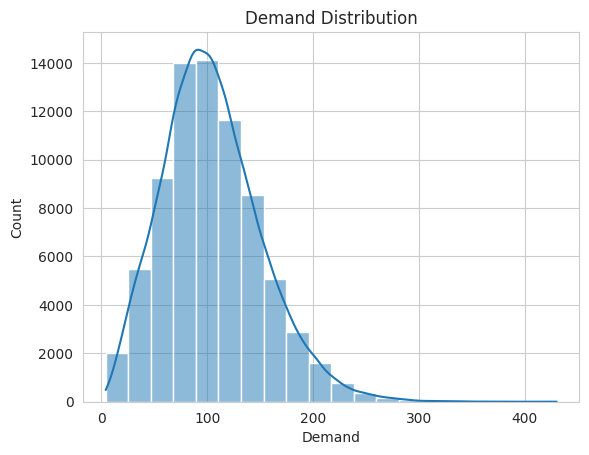

In [60]:
sns.histplot(df["Demand"], bins = 20, kde= True )
plt.title("Demand Distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

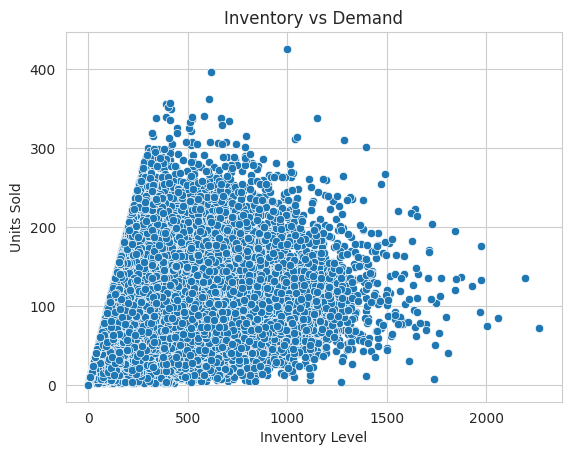

In [62]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory vs Demand")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

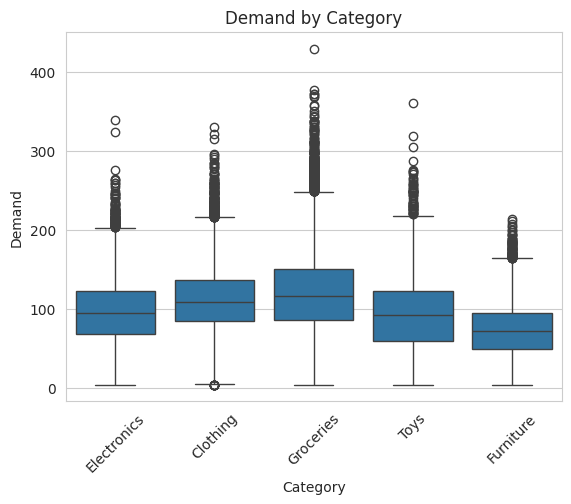

In [64]:
sns.boxplot(data = df, x = "Category", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Category")
plt.show

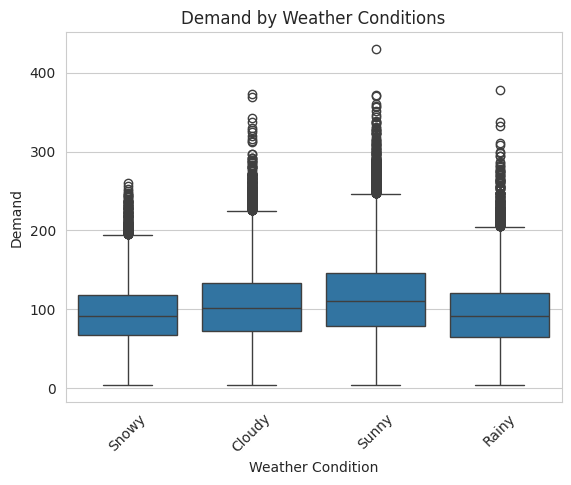

In [65]:
sns.boxplot(data = df, x = "Weather Condition", y = "Demand")
plt.xticks(rotation = 45)
plt.title("Demand by Weather Conditions")
plt.show()

In [67]:
monthly_demand = df.groupby("Month")["Demand"].sum()
monthly_demand

,Demand
Month,
1,975568
2,520142
3,704406
4,556900
5,536431
6,704076
7,629682
8,742781
9,644589


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

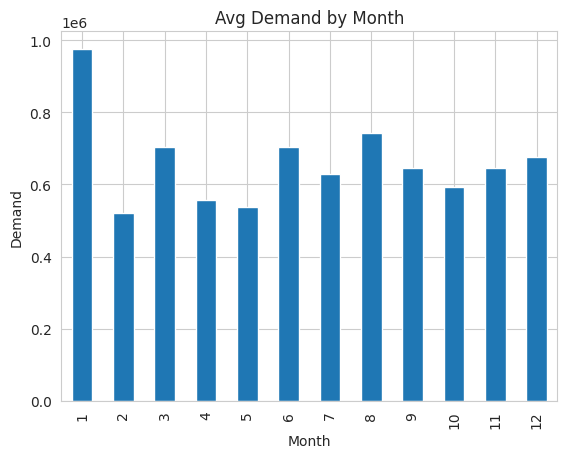

In [72]:
monthly_demand.plot(kind = "bar")
plt.title("Avg Demand by Month")
plt.xlabel("Month")
plt.ylabel("Demand")
plt

In [73]:
daily_demand = df.groupby("Date")["Demand"].sum()
daily_demand

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724
...,...
2024-01-26,11182
2024-01-27,11540
2024-01-28,11440


<function matplotlib.pyplot.show(close=None, block=None)>

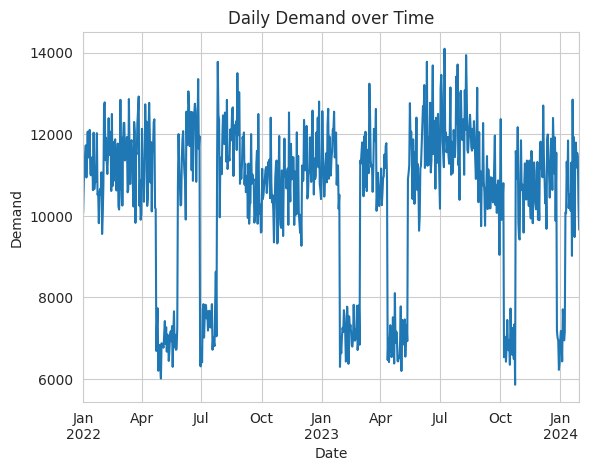

In [76]:
 daily_demand.plot()
 plt.title("Daily Demand over Time")
 plt.xlabel("Date")
 plt.ylabel("Demand")
 plt.show

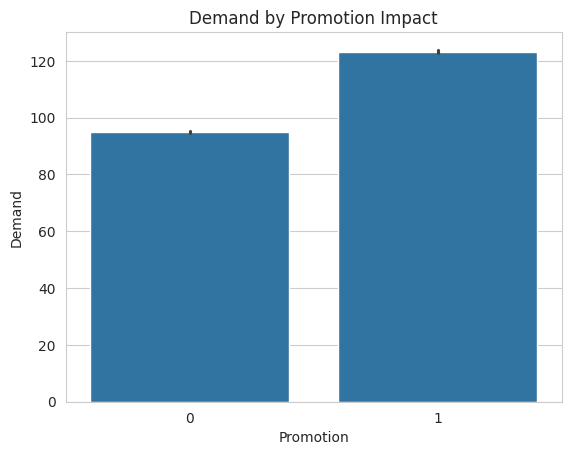

In [77]:
sns.barplot(x = "Promotion", y = "Demand", data = df)
plt.title("Demand by Promotion Impact")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

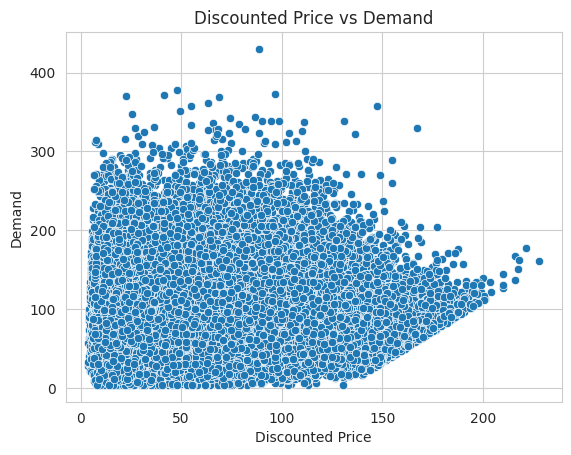

In [81]:
sns.scatterplot(data = df, x = "Discounted Price", y = "Demand")
plt.title("Discounted Price vs Demand")
plt.show

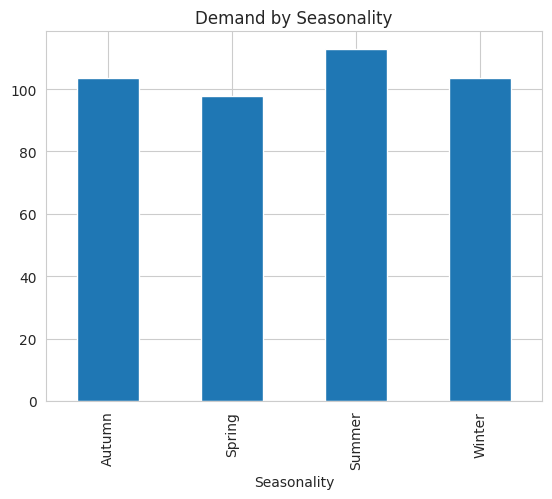

In [83]:
df.groupby("Seasonality")["Demand"].mean( ).plot(kind = "bar", title = "Demand by Seasonality")
plt.show()

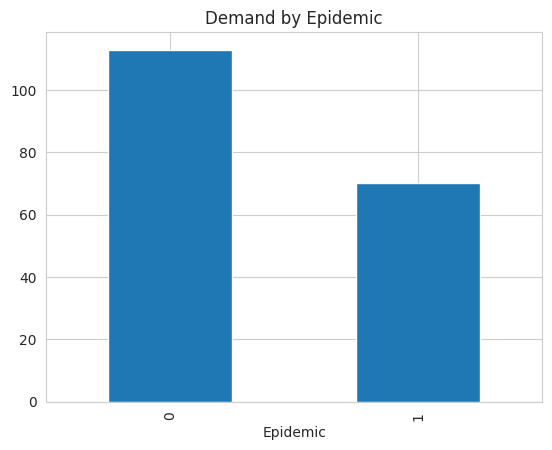

In [85]:
df.groupby("Epidemic")["Demand"].mean().plot (kind = "bar", title = "Demand by Epidemic")
plt.show()

In [87]:
df.to_csv("Cleaned Data Forecasting.csv")

In [93]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pickle

In [94]:
df = pd.read_csv("/demand_forecasting.csv")

In [97]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [99]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [102]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [104]:
target = "Demand"

In [106]:
X = df[features].copy()

In [108]:
Y = df[target]

In [111]:
from pandas.core.arrays import categorical
label_encoders = {}

categorical_columns = X.select_dtypes(include=["object"]).columns

In [113]:
categorical_columns

Index(['Category'], dtype='object')

In [116]:
for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [118]:
label_encoders

{'Category': LabelEncoder()}

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [122]:
xgb = XGBRegressor(objective = "reg:squarederror", n_jobs = -1)

In [124]:
parametere_dict = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3,4,6,8],
    "learning_rate" : [0.01, 0.05, 0.1],
    "subsample" : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5]
}


In [128]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = parametere_dict,
    n_iter = 25,
    scoring = "neg_mean_squared_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [129]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error', verbose=1)

In [131]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [134]:
best_model = random_search.best_estimator_

In [136]:
y_pred = best_model.predict(X_test)

In [144]:
mean_squared_error(y_test, y_pred, squared = False)

TypeError: got an unexpected keyword argument 'mean_squared'